# PREDICTING ENERGY CONSUMPTION

## 1. Imports and load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Energy Consumption.csv")
df.shape

(52966, 3)

In [3]:
df.head()

,Start time UTC,End time UTC,Electricity consumption (MWh)
0,31-12-2015 21:00,31-12-2015 22:00,10800
1,31-12-2015 22:00,31-12-2015 23:00,10431
2,31-12-2015 23:00,01-01-2016 00:00,10005
3,01-01-2016 00:00,01-01-2016 01:00,9722
4,01-01-2016 01:00,01-01-2016 02:00,9599


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52966 entries, 0 to 52965
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Start time UTC                 52966 non-null  object
 1   End time UTC                   52966 non-null  object
 2   Electricity consumption (MWh)  52966 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [5]:
df.describe()

,Electricity consumption (MWh)
count,52966.000000
mean,9488.750519
std,1576.241673
min,5341.000000
25%,8322.000000
50%,9277.000000
75%,10602.000000
max,15105.000000


## 2. EDA (Exploratory Data Analysis)

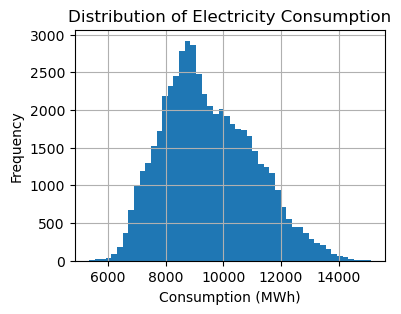

In [6]:
plt.figure(figsize=(4,3))
df["Electricity consumption (MWh)"].hist(bins=50)
plt.title("Distribution of Electricity Consumption")
plt.xlabel("Consumption (MWh)")
plt.ylabel("Frequency")
plt.show()

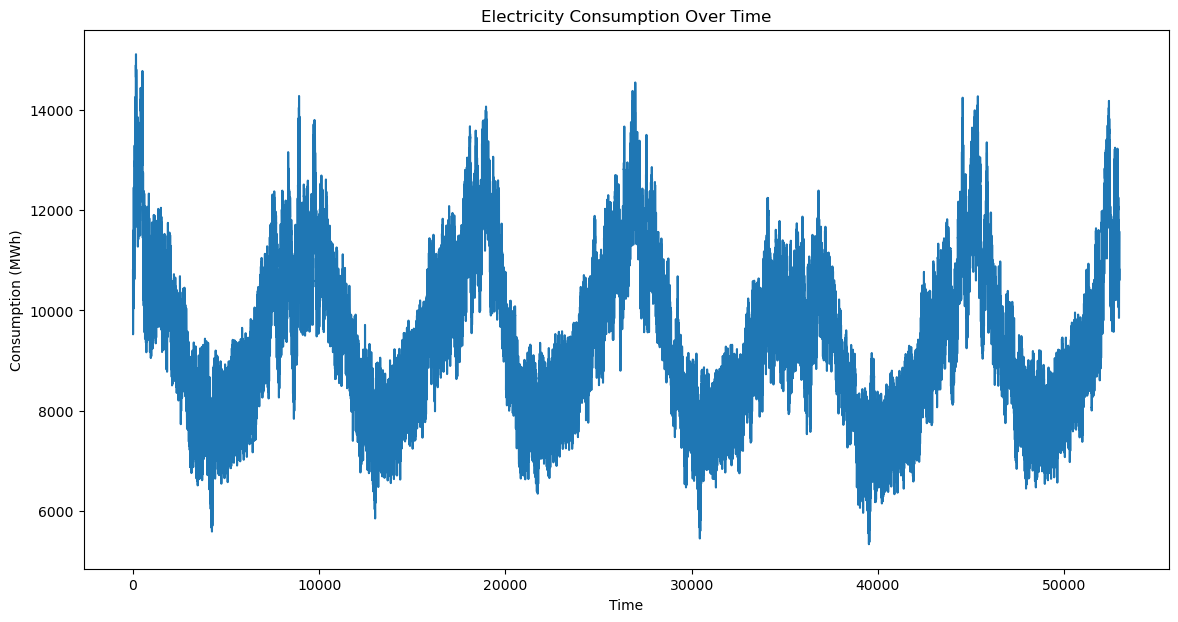

In [7]:
plt.figure(figsize=(14,7))
plt.plot(df["Electricity consumption (MWh)"])
plt.title("Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Consumption (MWh)")
plt.show()

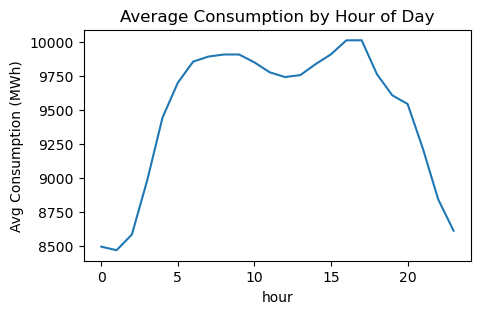

In [8]:
df["Start time UTC"] = pd.to_datetime(df["Start time UTC"], dayfirst=True)
df["hour"] = df["Start time UTC"].dt.hour

hourly_avg = df.groupby("hour")["Electricity consumption (MWh)"].mean()

hourly_avg.plot(figsize=(5,3))
plt.title("Average Consumption by Hour of Day")
plt.ylabel("Avg Consumption (MWh)")
plt.show()

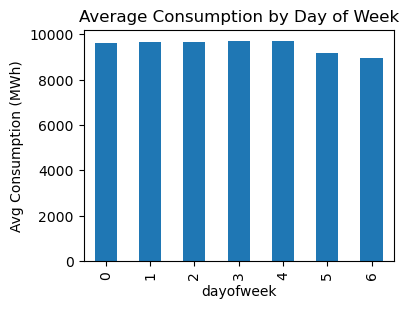

In [9]:
df["dayofweek"] = df["Start time UTC"].dt.dayofweek

dow_avg = df.groupby("dayofweek")["Electricity consumption (MWh)"].mean()

dow_avg.plot(kind="bar", figsize=(4,3))
plt.title("Average Consumption by Day of Week")
plt.ylabel("Avg Consumption (MWh)")
plt.show()

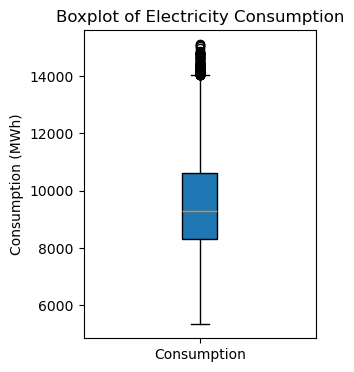

In [10]:
plt.figure(figsize=(3,4))

plt.boxplot(
    df["Electricity consumption (MWh)"],
    vert=True,
    patch_artist=True,
    boxprops=dict(),
    medianprops=dict(),
)

plt.title("Boxplot of Electricity Consumption", fontsize=12)
plt.ylabel("Consumption (MWh)")
plt.xticks([1], ["Consumption"])

plt.show()

## 3. Preprocessing of Data

In [11]:
df["Start time UTC"] = pd.to_datetime(df["Start time UTC"], dayfirst=True)

In [12]:
# in our data few Start time are not rounded like 16:05 to 16:00
df["hour"] = df["Start time UTC"].dt.floor("H")

df = (
    df.groupby("hour")["Electricity consumption (MWh)"]
    .mean()
    .reset_index()
)

df = df.set_index("hour")

C:\Users\neelj\AppData\Local\Temp\ipykernel_1092\51785374.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour"] = df["Start time UTC"].dt.floor("H")


In [13]:
df = df.rename(columns={"Electricity consumption (MWh)": "consumption"})

In [14]:
print("After preprocessing shape:", df.shape)
df.head()

After preprocessing shape: (52442, 1)


,consumption
hour,
2015-12-31 21:00:00,10800.0
2015-12-31 22:00:00,10431.0
2015-12-31 23:00:00,10005.0
2016-01-01 00:00:00,9722.0
2016-01-01 01:00:00,9599.0


## 3. Handling missing vals and Outliers

In [15]:
# missing values
print(df.isnull().sum())
df["consumption"] = df["consumption"].interpolate(method="time")

consumption    0
dtype: int64


In [16]:
## IQR for outlier

Q1 = df["consumption"].quantile(0.25)
Q3 = df["consumption"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

4893.5 14041.5


In [17]:
df["consumption"] = df["consumption"].clip(lower=lower_bound, upper=upper_bound)

## 5. Feature Engineering (imp.)

In [18]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["year"] = df.index.year
df["dayofyear"] = df.index.dayofyear
df["weekofyear"] = df.index.isocalendar().week.astype(int)
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [19]:
# rolling stats.
df["rolling_mean_24"] = df["consumption"].rolling(window=24).mean()
df["rolling_std_24"] = df["consumption"].rolling(window=24).std()

In [20]:
# lags
df["lag_1"] = df["consumption"].shift(1)
df["lag_24"] = df["consumption"].shift(24)
df["lag_168"] = df["consumption"].shift(168)  # for week

In [21]:
# cyclical encodng
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [22]:
df = df.dropna()

print("After feature engineering shape:", df.shape)
df.head()

After feature engineering shape: (52274, 19)


,consumption,hour,day_of_week,month,year,dayofyear,weekofyear,is_weekend,rolling_mean_24,rolling_std_24,lag_1,lag_24,lag_168,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
hour,,,,,,,,,,,,,,,,,,,
2016-01-07 21:00:00,14041.5,21,3,1,2016,7,1,0,13793.208333,453.562299,14041.5,13672.0,10800.0,-0.707107,0.707107,0.433884,-0.900969,0.5,0.866025
2016-01-07 22:00:00,13643.0,22,3,1,2016,7,1,0,13808.125000,441.857646,14041.5,13285.0,10431.0,-0.500000,0.866025,0.433884,-0.900969,0.5,0.866025
2016-01-07 23:00:00,13369.0,23,3,1,2016,7,1,0,13823.041667,419.241575,13643.0,13011.0,10005.0,-0.258819,0.965926,0.433884,-0.900969,0.5,0.866025
2016-01-08 00:00:00,13142.0,0,4,1,2016,8,1,0,13836.416667,389.983129,13369.0,12821.0,9722.0,0.000000,1.000000,-0.433884,-0.900969,0.5,0.866025
2016-01-08 01:00:00,13111.0,1,4,1,2016,8,1,0,13848.500000,360.534115,13142.0,12821.0,9599.0,0.258819,0.965926,-0.433884,-0.900969,0.5,0.866025


In [23]:
## saving csv to our folder
df.to_csv("Cleaned_Power_Consumption.csv")

## 6. Train-Test Split & Feature selection

In [24]:
FEATURES = [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos","is_weekend",
    "lag_1", "lag_24", "lag_168",
    "rolling_mean_24", "rolling_std_24"
]

TARGET = "consumption"

In [25]:
# splitting
split_date = "2021-01-01"   # assumed above this date is apx. 20% of data for test

train = df[df.index < split_date]
test  = df[df.index >= split_date]

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (43517, 12)
Test shape: (8757, 12)


## 7. Randomforest (1st model)

In [26]:
# define model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [27]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 15, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_absolute_error', verbose=1)

In [28]:
# best parameters testing
best_rf = grid_rf.best_estimator_
print("Best Parameters:", grid_rf.best_params_)

rf_preds = best_rf.predict(X_test)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [29]:
# evaluation
mae_rf = mean_absolute_error(y_test, rf_preds)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_preds))
r2_rf = r2_score(y_test, rf_preds)

print("Random Forest Performance")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Performance
MAE: 70.30739579764762
RMSE: 96.70127993346439
R2: 0.9966785985486724


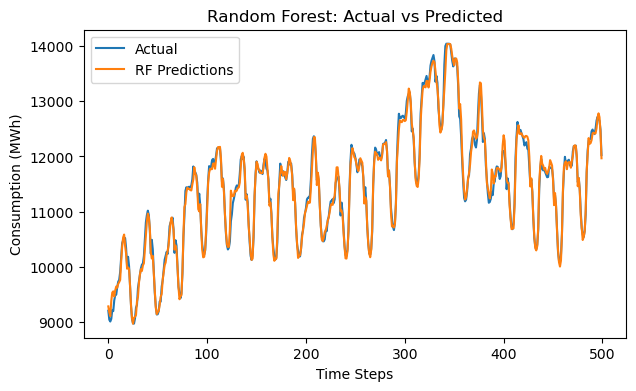

In [30]:
plt.figure(figsize=(7,4))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(rf_preds[:500], label="RF Predictions")

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Consumption (MWh)")

plt.legend()
plt.show()

## 8. XGBoost (2nd model)

In [31]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [32]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=1,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.03, 0.05, 0.1],
                         'max_depth': [4, 6, 8], 'n_estimators': [200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_absolute_error', verbose=1)

In [33]:
# model with best params.

best_xgb = grid_xgb.best_estimator_
print("Best Parameters:", grid_xgb.best_params_)

xgb_preds = best_xgb.predict(X_test)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}


In [34]:
# evaluation

mae_xgb = mean_absolute_error(y_test, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))
r2_xgb = r2_score(y_test, xgb_preds)

print("XGBoost Performance")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Performance
MAE: 62.472629876009904
RMSE: 84.82653467052066
R2: 0.9974442381834466


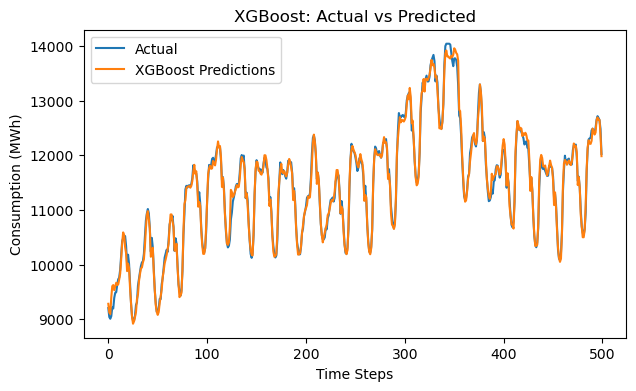

In [35]:
plt.figure(figsize=(7,4))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(xgb_preds[:500], label="XGBoost Predictions")

plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Consumption (MWh)")

plt.legend()
plt.show()

## 9. Linear Regression (3rd model)

In [36]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [37]:
lr_preds = lr_model.predict(X_test)

In [38]:
mae_lr = mean_absolute_error(y_test, lr_preds)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_preds))
r2_lr = r2_score(y_test, lr_preds)

print("Linear Regression Performance")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Performance
MAE: 141.536362021465
RMSE: 182.94654056831033
R2: 0.9881120949012392


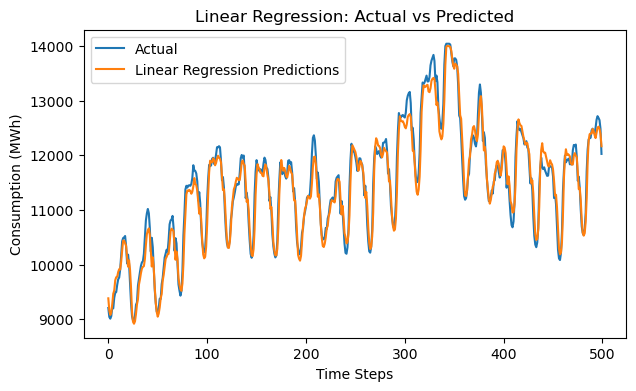

In [39]:
plt.figure(figsize=(7,4))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(lr_preds[:500], label="Linear Regression Predictions")

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Consumption (MWh)")

plt.legend()
plt.show()

## 10. Evaluation Metrix [Comparision of all]

In [40]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Linear Regression"],
    "MAE": [mae_rf, mae_xgb, mae_lr],
    "RMSE": [rmse_rf, rmse_xgb, rmse_lr],
    "R2 Score": [r2_rf, r2_xgb, r2_lr]
})

results

,Model,MAE,RMSE,R2 Score
0,Random Forest,70.307396,96.701280,0.996679
1,XGBoost,62.472630,84.826535,0.997444
2,Linear Regression,141.536362,182.946541,0.988112


## 11. Error Patterns

In [41]:
# make a safe copy and reset index so no ambiguity
err_df = pd.DataFrame({
    "actual": y_test.values,
    "xgb_error": np.abs(y_test.values - xgb_preds),
    "rf_error": np.abs(y_test.values - rf_preds),
    "lr_error": np.abs(y_test.values - lr_preds),
}, index=y_test.index)

# move datetime index to column
err_df = err_df.reset_index().rename(columns={"hour": "timestamp"})

# create time features from timestamp
err_df["hour"] = err_df["timestamp"].dt.hour
err_df["month"] = err_df["timestamp"].dt.month
err_df["day_of_week"] = err_df["timestamp"].dt.dayofweek

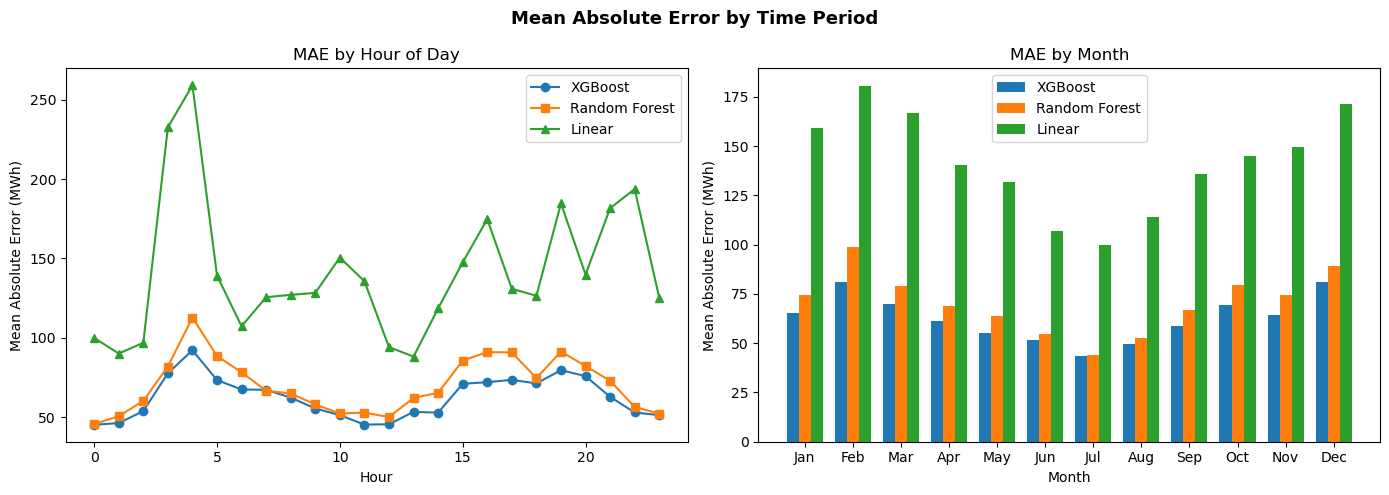

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mean Absolute Error by Time Period", fontsize=13, fontweight="bold")

# MAE by Hour
hr = err_df.groupby("hour")[["xgb_error","rf_error","lr_error"]].mean()

axes[0].plot(hr.index, hr["xgb_error"], marker="o", label="XGBoost")
axes[0].plot(hr.index, hr["rf_error"], marker="s", label="Random Forest")
axes[0].plot(hr.index, hr["lr_error"], marker="^", label="Linear")
axes[0].set_title("MAE by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean Absolute Error (MWh)")
axes[0].legend()

# MAE by Month
months_short = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
mo = err_df.groupby("month")[["xgb_error","rf_error","lr_error"]].mean()

x = np.arange(len(mo))
axes[1].bar(x-0.25, mo["xgb_error"], width=0.25, label="XGBoost")
axes[1].bar(x, mo["rf_error"], width=0.25, label="Random Forest")
axes[1].bar(x+0.25, mo["lr_error"], width=0.25, label="Linear")
axes[1].set_xticks(x)
axes[1].set_xticklabels(months_short)
axes[1].set_title("MAE by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean Absolute Error (MWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Predicting Next Year

In [43]:
avg_consumption = df["consumption"].mean().round(2)
print("Approx hourly consumption next year:", avg_consumption)

Approx hourly consumption next year: 9485.99


In [44]:
yearly_estimate = avg_consumption * 24 * 365
print("Approx total next-year consumption:", yearly_estimate.round(2))

Approx total next-year consumption: 83097272.4


## 13. Conclusion